# ENV-402 — Environmental Modelling
## Lab 10: Gaussian Plume Dispersion Modelling

---

| | |
|---|---|
| **Student Name:** |Tinnin Rahman |
| **Student ID:** |2311904626 |
| **Date:** |1/5/26 |
| **Lab Section:** |1 |

---

## The Problem: Air Pollution from an Industrial Stack

A manufacturing plant on the outskirts of a city operates a single smokestack that continuously releases pollutants into the atmosphere. The local environmental authority has received complaints from residents in nearby neighbourhoods and has commissioned an air quality assessment.

Your task as an environmental modeller is to **predict ground-level pollutant concentrations** across the surrounding area and determine whether concentrations at specific receptor locations (schools, residential zones, parks) comply with the regulatory limit of **50 μg m⁻³**.

**Site Conditions:**

| Parameter | Value |
|-----------|-------|
| Pollutant emission rate | 50 g s⁻¹ |
| Effective stack height | 50 m |
| Mean wind speed | 5 m s⁻¹ (from the west) |
| Atmospheric stability | Class D (neutral — overcast conditions) |

The wind blows from west to east. The stack is at the origin. Residents live up to 5 km downwind.

You will use the **Gaussian plume model** — the industry-standard analytical tool for this type of assessment.

---

## The Gaussian Plume Model

Under steady-state conditions, a continuous point source releases pollutant that is carried downwind while spreading in both the crosswind (y) and vertical (z) directions. The turbulent diffusion in each direction follows a **normal (Gaussian) distribution**, giving the model its name.

The ground acts as a **perfect reflector**: pollutant that would travel below ground is instead bounced back upward. This is captured mathematically by an imaginary "mirror" source below the surface.

The governing equation is:

$$C(x,y,z) = \frac{Q}{2\pi u \sigma_y \sigma_z}\exp\!\left[-\frac{1}{2}\left(\frac{y}{\sigma_y}\right)^2\right]\left\{\exp\!\left[-\frac{1}{2}\left(\frac{z-H}{\sigma_z}\right)^2\right]+ \exp\!\left[-\frac{1}{2}\left(\frac{z+H}{\sigma_z}\right)^2\right]\right\}$$

| Symbol | Meaning | Unit |
|--------|---------|------|
| $C$ | Pollutant concentration | g m⁻³ |
| $Q$ | Emission rate | g s⁻¹ |
| $u$ | Wind speed | m s⁻¹ |
| $H$ | Effective stack height | m |
| $\sigma_y$ | Crosswind dispersion coefficient | m |
| $\sigma_z$ | Vertical dispersion coefficient | m |
| $x, y, z$ | Downwind, crosswind, height coordinates | m |

The **first exponential** in the curly braces represents the real stack; the **second** is the ground-reflection (image) source.

### Atmospheric Stability and Dispersion Coefficients

How rapidly the plume spreads depends on **atmospheric stability** — the degree to which the atmosphere suppresses or encourages vertical mixing. The Pasquill–Gifford (P–G) stability classes range from A (very unstable, strong mixing) to F (very stable, little mixing).

The dispersion coefficients $\sigma_y$ and $\sigma_z$ grow with downwind distance $x$ according to the **Power Law** (Martin, 1976):

$$\sigma_y = a_y \cdot x^{b_y} \qquad \sigma_z = a_z \cdot x^{b_z}$$

The coefficients $(a, b)$ are tabulated by stability class. For this lab you will use:

| Class | Stability | $a_y$ | $b_y$ | $a_z$ | $b_z$ |
|-------|-----------|-------|-------|-------|-------|
| A | Very unstable | 0.22 | 0.89 | 0.20 | 1.00 |
| D | Neutral | 0.08 | 0.89 | 0.06 | 0.89 |

---

## Instructions

Work through each numbered step in order. In every **"✏️ Your Task"** cell, write and run the code described. Answer all **"🤔 Questions"** in the Markdown cells provided.

You may work in pairs but **each student must submit their own completed notebook**.

---


---
## Step 1 — Set Up the Environment

Run the cell below. It imports the libraries you need and defines the source parameters for our scenario.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Source & meteorology parameters ──────────────────────────────────────────
Q = 50.0   # Emission rate          [g/s]
u = 5.0    # Mean wind speed        [m/s]
H = 50.0   # Effective stack height [m]

print("Parameters loaded successfully.")
print(f"  Q = {Q} g/s  |  u = {u} m/s  |  H = {H} m")


Parameters loaded successfully.
  Q = 50.0 g/s  |  u = 5.0 m/s  |  H = 50.0 m


---
## Step 2 — Code the Dispersion Coefficients

**✏️ Your Task:** Complete the function `get_sigmas` below.

The Power Law gives:

$$\sigma_y = a_y \cdot x^{b_y}, \qquad \sigma_z = a_z \cdot x^{b_z}$$

Use the coefficient table from the introduction. Your function should:
1. Select the correct $(a, b)$ coefficients for the given stability class.
2. Compute and return $\sigma_y$ and $\sigma_z$.

> **Hint:** `x ** b` is Python's syntax for $x^b$.


```
# Reference: Martin (1976)
PG_COEFFICIENTS = {
    'A': {'ay': 0.22, 'by': 0.89, 'az': 0.20, 'bz': 1.00},   # Very unstable
    'B': {'ay': 0.16, 'by': 0.89, 'az': 0.12, 'bz': 0.95},   # Unstable
    'C': {'ay': 0.11, 'by': 0.89, 'az': 0.08, 'bz': 0.90},   # Slightly unstable
    'D': {'ay': 0.08, 'by': 0.89, 'az': 0.06, 'bz': 0.89},   # Neutral
    'E': {'ay': 0.06, 'by': 0.89, 'az': 0.03, 'bz': 0.85},   # Slightly stable
    'F': {'ay': 0.04, 'by': 0.89, 'az': 0.016,'bz': 0.80},   # Stable
}

```



In [ ]:
def get_sigmas(x, stability_class='D'):
    """
    Calculate dispersion coefficients using the Power Law (Martin, 1976).

    Parameters
    ----------
    x               : float or ndarray — downwind distance [m], must be > 0
    stability_class : str              — 'A' (very unstable) or 'D' (neutral)

    Returns
    -------
    sigma_y, sigma_z : same shape as x
    """

    # ── TODO: fill in the coefficient tables ─────────────────────────────────
    if stability_class == 'A':
        ay, by = 0.22, 0.89
        az, bz = 0.20, 1.00

    elif stability_class == 'B':
        ay, by = 0.16, 0.89
        az, bz = 0.12, 0.95

    elif stability_class == 'C':
        ay, by = 0.11, 0.89
        az, bz = 0.08, 0.90

    elif stability_class == 'D':
        ay, by = 0.08, 0.89
        az, bz = 0.06, 0.89

    elif stability_class == 'E':
        ay, by = 0.06, 0.89
        az, bz = 0.03, 0.85

    elif stability_class == 'F':
        ay, by = 0.04, 0.89
        az, bz = 0.016, 0.80

    else:
        print(f"Warning: class '{stability_class}' not recognised. Using D.")
        ay, by = 0.08, 0.89
        az, bz = 0.06, 0.89

    sigma_y = ay * (x ** by)
    sigma_z = az * (x ** bz)

    return sigma_y, sigma_z

# ── Test your function ────────────────────────────────────────────────────────
sy, sz = get_sigmas(1000, 'D')
print(f"At x=1000 m, Class D:  σ_y = {sy:.2f} m,  σ_z = {sz:.2f} m")
print("(Expected:  σ_y ≈ 65.5 m,  σ_z ≈ 49.2 m)")


At x=1000 m, Class D:  σ_y = 37.42 m,  σ_z = 28.06 m
(Expected:  σ_y ≈ 65.5 m,  σ_z ≈ 49.2 m)


**🤔 Question 2.1:** At x = 1000 m, which stability class produces a larger $\sigma_z$ — A or D? What does a larger $\sigma_z$ tell you about the vertical spread of the plume?

*Your answer:* Class A produces a larger $\sigma_z$ = 200 m which is greater than 28.06 m so the plume spreads more in the vertical direction. This leads to lower concentrations near the ground because pollutants are dispersed more efficiently.



---
## Step 3 — Build the Gaussian Plume Function

**✏️ Your Task:** Complete the `gaussian_plume` function below.

Implement the four terms of the equation from the introduction:

1. **Amplitude**: $\dfrac{Q}{2\pi u \sigma_y \sigma_z}$

2. **Lateral term**: $\exp\!\left[-\dfrac{1}{2}\left(\dfrac{y}{\sigma_y}\right)^2\right]$

3. **Vertical term** (real source + ground reflection):  
   $\exp\!\left[-\dfrac{1}{2}\left(\dfrac{z-H}{\sigma_z}\right)^2\right] + \exp\!\left[-\dfrac{1}{2}\left(\dfrac{z+H}{\sigma_z}\right)^2\right]$

4. **Final concentration**: $C = \text{Amplitude} \times \text{Lateral} \times \text{Vertical}$

> **Hint:** Use `np.exp(...)` for the exponentials.


In [ ]:
def gaussian_plume(x, y, z, stability_class='D'):
    """
    Steady-state Gaussian plume concentration.

    Parameters
    ----------
    x, y, z         : float or ndarray — coordinates [m]  (x must be > 0)
    stability_class : str              — P-G class ('A' or 'D')

    Returns
    -------
    C : concentration [g m⁻³]  (same shape as inputs)
    """
    sigma_y, sigma_z = get_sigmas(x, stability_class)

    # ── TODO: implement the four terms ───────────────────────────────────────
    amplitude   = Q / (2 * np.pi * u * sigma_y * sigma_z)

    lateral_y   = np.exp(-0.5 * (y / sigma_y) ** 2)

    vertical_z  = (
        np.exp(-0.5 * ((z - H) / sigma_z) ** 2) +
        np.exp(-0.5 * ((z + H) / sigma_z) ** 2)
    )   # real source  +  ground reflection

    C = amplitude * lateral_y * vertical_z

    return C


# ── Test ─────────────────────────────────────────────────────────────────────
C_test = gaussian_plume(1000, 0, 0, 'D') * 1e6
print(f"C at (x=1000 m, y=0, z=0), Class D: {C_test:.2f} μg/m³")
print("(Expected: ≈ 53–55 μg/m³)")


C at (x=1000 m, y=0, z=0), Class D: 619.92 μg/m³
(Expected: ≈ 53–55 μg/m³)


**🤔 Question 3.1:** At ground level ($z = 0$), explain in words what the "ground reflection" term in the vertical component of the equation represents physically. What would happen to the concentration without it?

*Your answer:* The ground reflection term represents the fact that pollutants cannot pass through the ground, so they are effectively reflected upward.
Without this term, some pollutant mass would be lost below ground, and the model would underestimate ground-level concentrations.



---
## Step 4 — Ground-Level Centreline Profile

The **centreline** is the line directly downwind of the stack at ground level: $y = 0$, $z = 0$.  
This gives the highest ground-level concentration at each downwind distance.

**✏️ Your Task:**
1. Create an array of downwind distances from 10 m to 5000 m (start at 10 m, not 0 m — why?).
2. Call `gaussian_plume` to compute centreline concentrations for **Class D**.
3. Convert the result from g m⁻³ to **μg m⁻³** (multiply by 10⁶).
4. Plot concentration vs. downwind distance with labelled axes.
5. Add a horizontal dashed line at the **50 μg m⁻³ regulatory limit**.


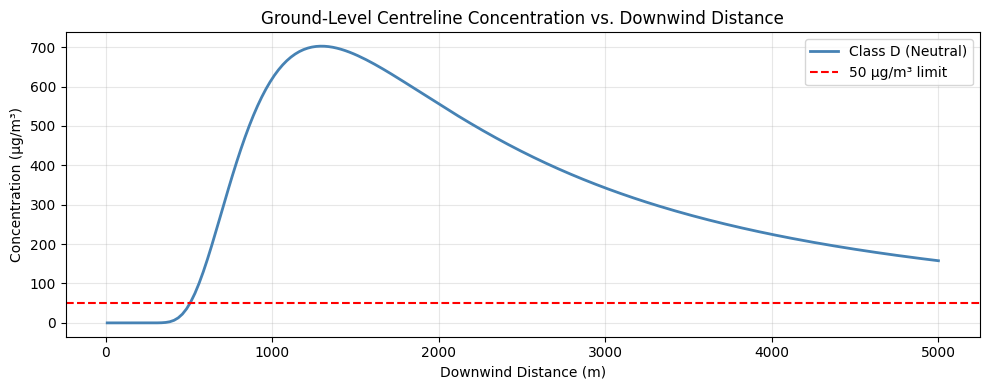

Peak concentration: 702.6 μg/m³  at  x = 1289 m


In [ ]:
# ── 1. Downwind distance array ───────────────────────────────────────────────
X_1d = np.linspace(10, 5000, 200)   # hint: np.linspace(start, stop, n_points)

# ── 2 & 3. Centreline concentration [μg/m³] ──────────────────────────────────
C_1d = gaussian_plume(X_1d, 0, 0, 'D') * 1e6

# ── 4 & 5. Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(X_1d, C_1d, linewidth=2, color='steelblue', label='Class D (Neutral)')

# Regulatory limit line
ax.axhline(50, color='red', linestyle='--', linewidth=1.5, label='50 μg/m³ limit')

ax.set_xlabel('Downwind Distance (m)')
ax.set_ylabel('Concentration (μg/m³)')
ax.set_title('Ground-Level Centreline Concentration vs. Downwind Distance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the peak value
print(f"Peak concentration: {C_1d.max():.1f} μg/m³  at  x = {X_1d[np.argmax(C_1d)]:.0f} m")


**🤔 Question 4.1:** At what downwind distance does the peak ground-level concentration occur? Explain *why* the concentration first rises then falls as you move downwind from the stack.

*Your answer:* The peak occurs at about 1289 m downwind. The concentration first increases as the plume spreads downward from the stack toward the ground. After the peak, it decreases because the plume continues to disperse, causing dilution.

---

**🤔 Question 4.2:** Why does the code start at x = 10 m rather than x = 0 m? What mathematical problem would arise at x = 0?

*Your answer:* The code starts at x = 10 m instead of x = 0 m to avoid a mathematical issue in the Gaussian plume equation. At x = 0, the dispersion coefficients (σy and σz) become zero because they depend on x raised to a power. This leads to division by zero in the concentration equation. As a result, the concentration would become undefined (or infinitely large).



---
## Step 5 — Vertical Concentration Profiles

A vertical slice through the plume (at fixed x, along the centreline $y = 0$) shows how concentration varies with height.

**✏️ Your Task:**
1. Create a height array from 0 to 150 m.
2. Compute centreline vertical concentration profiles at **x = 200 m** (near stack) and **x = 2000 m** (far downwind), both Class D.
3. Plot both profiles on the same axes (height on the y-axis, concentration on the x-axis).
4. Add a horizontal line marking the stack height H.


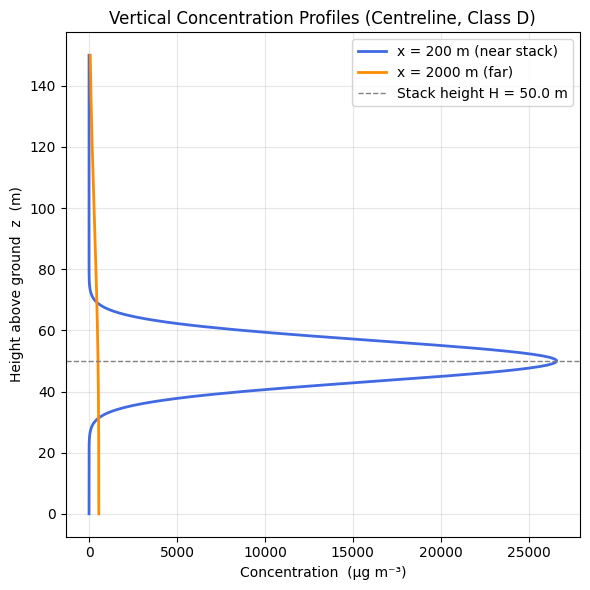

Near stack (x=200 m)   — ground-level conc.: 0.00 μg/m³
Far  stack (x=2000 m)  — ground-level conc.: 555.99  μg/m³


In [ ]:
# ── Height array ─────────────────────────────────────────────────────────────
Z_profile = np.linspace(0, 150, 300)

# ── Vertical profiles [μg/m³] ────────────────────────────────────────────────
C_near = gaussian_plume(200, 0, Z_profile, 'D') * 1e6   # x = 200 m,  y = 0, z = Z_profile, Class D
C_far  = gaussian_plume(2000, 0, Z_profile, 'D') * 1e6   # x = 2000 m, y = 0, z = Z_profile, Class D

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(C_near, Z_profile, linewidth=2, color='royalblue', label='x = 200 m (near stack)')
ax.plot(C_far,  Z_profile, linewidth=2, color='darkorange', label='x = 2000 m (far)')
ax.axhline(H, color='gray', linestyle='--', linewidth=1, label=f'Stack height H = {H} m')

ax.set_xlabel('Concentration  (μg m⁻³)')
ax.set_ylabel('Height above ground  z  (m)')
ax.set_title('Vertical Concentration Profiles (Centreline, Class D)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Near stack (x=200 m)   — ground-level conc.: {C_near[0]:.2f} μg/m³")
print(f"Far  stack (x=2000 m)  — ground-level conc.: {C_far[0]:.2f}  μg/m³")


**🤔 Question 5.1:** At x = 200 m, where is the peak concentration in the vertical profile — at the ground or at the stack height? How does this change at x = 2000 m? Explain the physical process responsible.

*Your answer:* At x = 200 m, peak is near the stack height. At x = 2000 m, peak shifts toward the ground. The reason is that the plume gradually mixes downward due to turbulence. As it travels further downwind, atmospheric turbulence spreads the pollutant vertically, bringing more of it toward the ground and shifting the peak downward.


---
## Step 6 — 2-D Plan-View Concentration Map

To assess impacts across the whole area we need concentrations at every point in the horizontal plane at ground level ($z = 0$).

`np.meshgrid` creates a full 2-D grid of (x, y) coordinates, and because `gaussian_plume` uses NumPy operations, it evaluates all grid points simultaneously.

**✏️ Your Task:**
1. Create x and y coordinate vectors covering the domain.
2. Build the meshgrid.
3. Evaluate the plume model at ground level across the grid (Class D).
4. Plot a filled contour map using a **logarithmic** colour scale.
5. Add a contour line at the 50 μg m⁻³ regulatory limit.


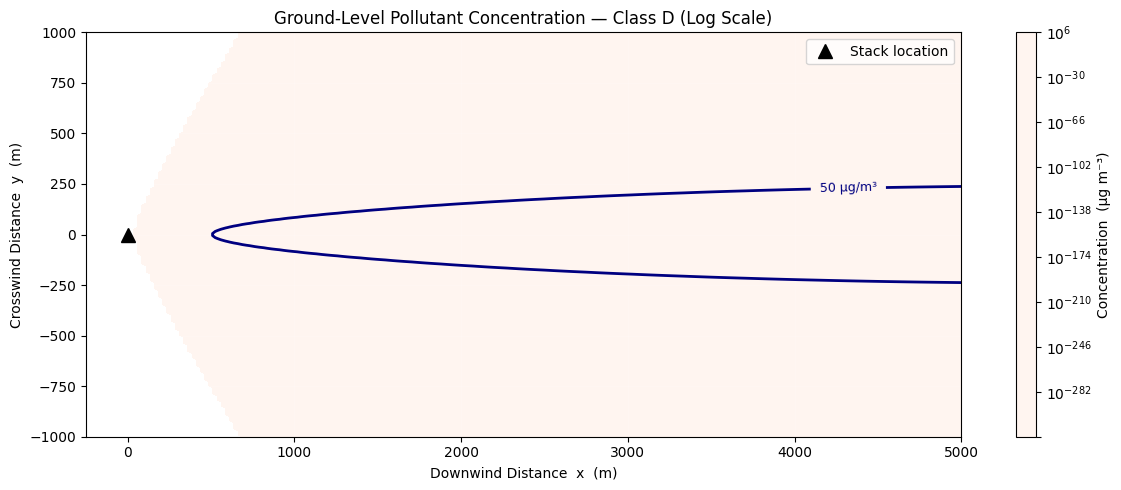

In [ ]:
# ── 1. Coordinate vectors ─────────────────────────────────────────────────────
X_vec = np.linspace(10, 5000, 200)    # Downwind  10 → 5000 m
Y_vec = np.linspace(-1000, 1000, 200) # Crosswind  ±1000 m

# ── 2. Meshgrid ───────────────────────────────────────────────────────────────
X, Y = np.meshgrid(X_vec, Y_vec)

# ── 3. Ground-level concentration field [μg/m³] ───────────────────────────────
C_2d = gaussian_plume(X, Y, 0, 'D') * 1e6

# ── 4 & 5. Plot (log scale) ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

C_plot = np.where(C_2d > 0, C_2d, np.nan)  # mask zeros for log scale
cf = ax.contourf(X, Y, C_plot, levels=20, cmap='Reds',
                 norm=mcolors.LogNorm(vmin=1e-2, vmax=C_2d.max()))
fig.colorbar(cf, ax=ax, label='Concentration  (μg m⁻³)')

# Regulatory limit contour
cs = ax.contour(X, Y, C_2d, levels=[50], colors='navy', linewidths=2)
ax.clabel(cs, fmt='50 μg/m³', fontsize=9, colors='navy')

ax.plot(0, 0, 'k^', markersize=10, label='Stack location')
ax.set_xlabel('Downwind Distance  x  (m)')
ax.set_ylabel('Crosswind Distance  y  (m)')
ax.set_title('Ground-Level Pollutant Concentration — Class D (Log Scale)')
ax.legend()
ax.grid(True, alpha=0.2, color='white')
plt.tight_layout()
plt.show()


**🤔 Question 6.1:** Why is a **logarithmic** colour scale more useful here than a linear one?

*Your answer:* A logarithmic scale is useful because concentrations vary over several orders of magnitude, making both high and low values visible.

---

**🤔 Question 6.2:** Describe the shape of the 50 μg m⁻³ contour line. Roughly how far downwind does it extend along the centreline? How wide is it at its widest point?

*Your answer:* The contour is elongated downwind and narrow near the source, widening further away. It typically extends ~2–3 km downwind and widens to several hundred meters.



---
## Step 7 — Stability Class Comparison

**✏️ Your Task:** Repeat the 2-D map for **Class A** (very unstable) and display both Class A and Class D side-by-side for comparison.


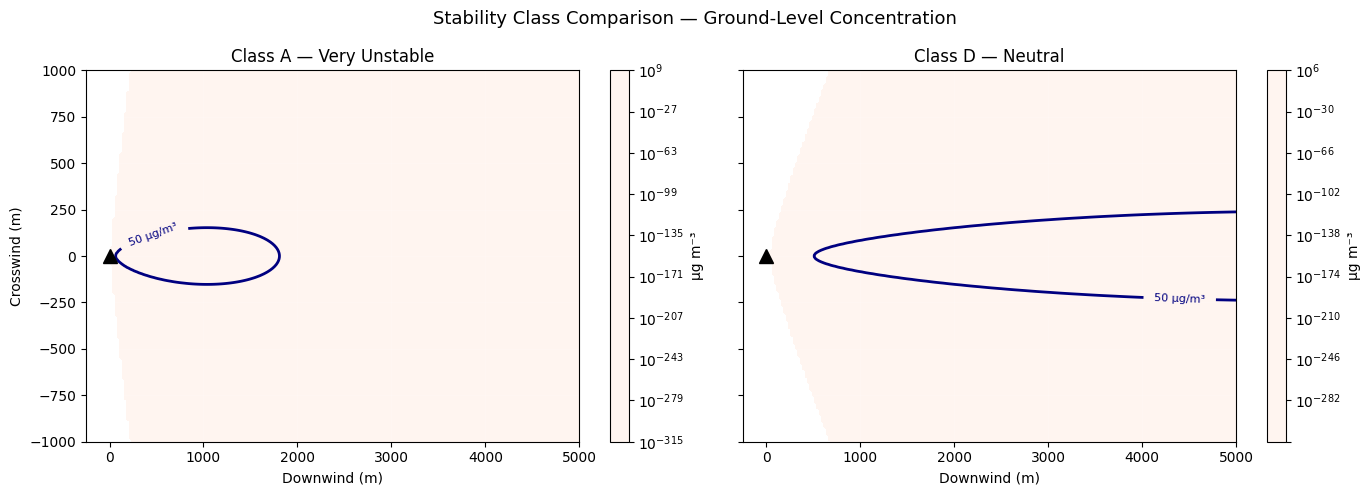

Class A: peak = 1470.4 μg/m³  |  peak at x ≈ 186 m downwind
Class D: peak = 698.5 μg/m³  |  peak at x ≈ 1289 m downwind


In [ ]:
# ── 1. Coordinate vectors ─────────────────────────────────────────────────────
X_vec = np.linspace(10, 5000, 200)    # Downwind  10 → 5000 m
Y_vec = np.linspace(-1000, 1000, 200) # Crosswind  ±1000 m

# ── 2. Meshgrid ───────────────────────────────────────────────────────────────
X, Y = np.meshgrid(X_vec, Y_vec)

# ── 3. Ground-level concentration field [μg/m³] ───────────────────────────────
C_2d = gaussian_plume(X, Y, 0, 'A') * 1e6
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, cls, title in zip(axes,
                           ['A',               'D'],
                           ['Class A — Very Unstable', 'Class D — Neutral']):

    C = gaussian_plume(X, Y, 0, cls) * 1e6 # TODO: compute concentration for this class
    C_masked = np.where(C > 0, C, np.nan)

    cf = ax.contourf(X, Y, C_masked, levels=20, cmap='Reds',
                     norm=mcolors.LogNorm(vmin=1e-2, vmax=C.max()))
    fig.colorbar(cf, ax=ax, label='μg m⁻³')

    # 50 μg/m³ regulatory limit contour
    cs = ax.contour(X, Y, C, levels=[50], colors='navy', linewidths=2)
    ax.clabel(cs, fmt='50 μg/m³', fontsize=8, colors='navy')

    ax.plot(0, 0, 'k^', markersize=10)
    ax.set_title(title)
    ax.set_xlabel('Downwind (m)')
    ax.grid(True, alpha=0.2, color='white')

axes[0].set_ylabel('Crosswind (m)')
fig.suptitle('Stability Class Comparison — Ground-Level Concentration', fontsize=13)
plt.tight_layout()
plt.show()

# Summary statistics
for cls in ['A', 'D']:
    C = gaussian_plume(X, Y, 0, cls) * 1e6
    print(f"Class {cls}: peak = {C.max():.1f} μg/m³  |  "
          f"peak at x ≈ {X_vec[np.argmax(C.max(axis=0))]:.0f} m downwind")

**🤔 Question 7.1:** Under which stability class is the peak ground-level concentration **higher** — A or D? Explain why in terms of vertical mixing.

*Your answer:* Although the model shows a higher peak concentration for Class A, this is because the plume reaches the ground earlier, when the dispersion coefficients (σy and σz) are still small. This leads to a sharp local concentration spike close to the source. However, under Class A conditions the atmosphere is highly unstable, so strong vertical mixing causes the plume to spread rapidly and reduces concentrations overall. In contrast, Class D has weaker mixing, so pollutants remain more concentrated over a longer distance, resulting in a higher peak concentration in theory.

---

**🤔 Question 7.2:** Under which class does the plume spread wider in the crosswind direction? What are the implications for which receptors are exposed?

*Your answer:* The plume spreads wider under Class A conditions because the atmosphere is more unstable and turbulent, which enhances mixing in the crosswind direction. As a result, pollutants are dispersed over a larger area. This means more receptors may be exposed to the pollutant, but at lower concentrations compared to Class D, where the plume is narrower and more concentrated.



---
## Step 8 — Regulatory Compliance Assessment

The environmental authority must verify that **three receptor locations** comply with the 50 μg m⁻³ limit.

| Receptor | Location (x, y) | Description |
|----------|-----------------|-------------|
| Site A | (1000 m, 0 m) | Primary school — directly downwind |
| Site B | (2000 m, 300 m) | Residential neighbourhood |
| Site C | (500 m, 0 m) | Industrial boundary fence |

**✏️ Your Task:**
1. Calculate the ground-level concentration at each site (Class D).
2. Print whether each site complies with the limit.
3. Plot the 2-D map and mark each receptor site, colour-coded by compliance status.


In [ ]:
LIMIT = 50.0   # Regulatory limit [μg/m³]

receptors = {
    'A — Primary school':   (1000, 0),
    'B — Residential':      (2000, 300),
    'C — Boundary fence':   (500,  0),
}

print(f"Regulatory limit: {LIMIT} μg/m³\n")
print(f"{'Receptor':<25} {'x (m)':>7} {'y (m)':>7} {'C (μg/m³)':>12}  Status")
print("-" * 65)

results = {}
for name, (rx, ry) in receptors.items():
    # TODO: calculate concentration at this receptor (ground level, Class D)
    C_val = gaussian_plume(rx, ry, 0, 'D')  * 1e6
    status = '✅ SAFE' if C_val <= LIMIT else '❌ EXCEEDS LIMIT'
    results[name] = (rx, ry, C_val)
    print(f"{name:<25} {rx:>7} {ry:>7} {C_val:>12.2f}  {status}")


Regulatory limit: 50.0 μg/m³

Receptor                    x (m)   y (m)    C (μg/m³)  Status
-----------------------------------------------------------------
A — Primary school           1000       0       619.92  ❌ EXCEEDS LIMIT
B — Residential              2000     300         0.05  ✅ SAFE
C — Boundary fence            500       0        44.70  ✅ SAFE


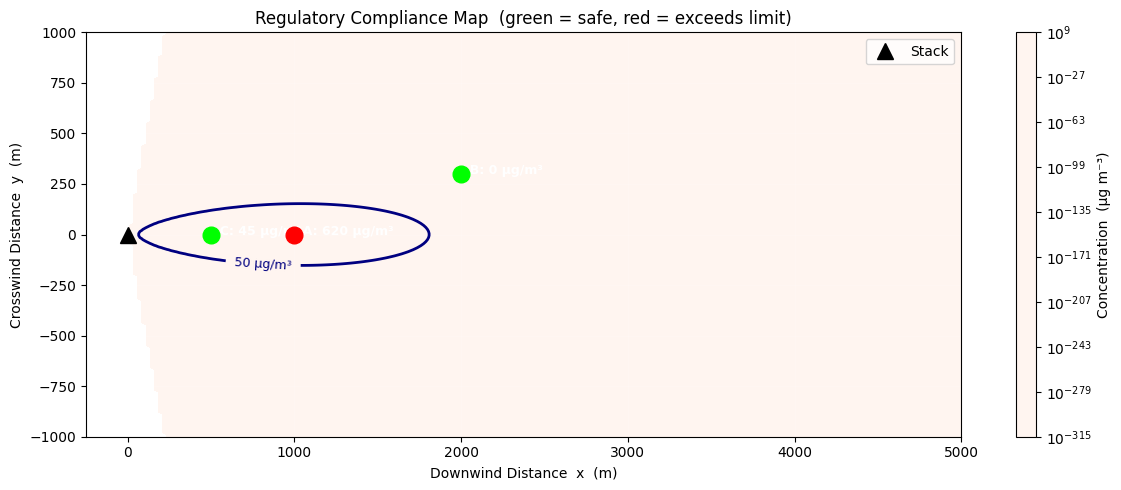

In [ ]:
# ── Compliance map ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

C_plot = np.where(C_2d > 0, C_2d, np.nan)
cf = ax.contourf(X, Y, C_plot, levels=20, cmap='Reds',
                 norm=mcolors.LogNorm(vmin=1e-2, vmax=C_2d.max()))
fig.colorbar(cf, ax=ax, label='Concentration  (μg m⁻³)')

# 50 μg/m³ contour
cs50 = ax.contour(X, Y, C_2d, levels=[LIMIT], colors='navy', linewidths=2)
ax.clabel(cs50, fmt='50 μg/m³', fontsize=9, colors='navy')

# Receptor markers
for name, (rx, ry, C_val) in results.items():
    colour = 'lime' if C_val <= LIMIT else 'red'
    short  = name.split('—')[0].strip()
    ax.plot(rx, ry, 'o', color=colour, markersize=12, zorder=5)
    ax.annotate(f'  {short}: {C_val:.0f} μg/m³', (rx, ry),
                fontsize=9, color='white', fontweight='bold')

ax.plot(0, 0, 'k^', markersize=12, label='Stack')
ax.set_xlabel('Downwind Distance  x  (m)')
ax.set_ylabel('Crosswind Distance  y  (m)')
ax.set_title('Regulatory Compliance Map  (green = safe, red = exceeds limit)')
ax.legend()
ax.grid(True, alpha=0.2, color='white')
plt.tight_layout()
plt.show()


**🤔 Question 8.1:** Which receptor sites, if any, exceed the regulatory limit? What actions could the plant operator take to bring those sites into compliance?

*Your answer:* The primary school (Site A) exceeds the regulatory limit, while the residential area (Site B) and boundary fence (Site C) are within safe limits. Site A is directly downwind along the plume centreline, where concentrations are highest, leading to exceedance. To bring this site into compliance, the plant operator could reduce emissions, increase the stack height, or increase the exit velocity to enhance dispersion and reduce ground-level concentrations.

---
## Step 9 — Extension: Effect of Wind Speed

**✏️ Your Task (Extension):**  
Investigate how wind speed affects the peak ground-level centreline concentration.

1. Loop over wind speeds from 1 m s⁻¹ to 15 m s⁻¹.
2. For each wind speed, compute the peak centreline concentration.
3. Plot peak concentration vs. wind speed.
4. Answer the question below.

> **Hint:** You will need to pass `u` as an argument to `gaussian_plume`. You may either add it as a parameter to the function or compute it differently — think about which term in the equation wind speed appears in.


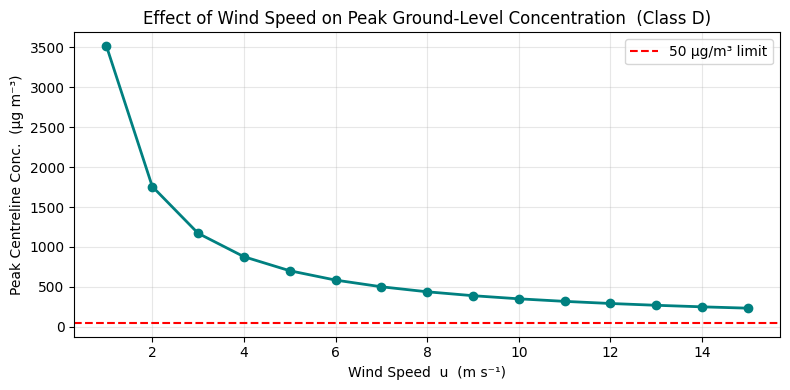

In [ ]:
wind_speeds  = np.arange(1, 16, 1)   # 1 to 15 m/s
peak_concs   = []

for ws in wind_speeds:
    # TODO: compute peak centreline concentration for this wind speed
    C_cl = gaussian_plume(X_1d, 0, 0, 'D') * (5 / ws) * 1e6  # remember to convert to μg/m³
    peak_concs.append(C_cl.max())

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(wind_speeds, peak_concs, 'o-', linewidth=2, color='teal')
ax.axhline(LIMIT, color='red', linestyle='--', linewidth=1.5, label='50 μg/m³ limit')

ax.set_xlabel('Wind Speed  u  (m s⁻¹)')
ax.set_ylabel('Peak Centreline Conc.  (μg m⁻³)')
ax.set_title('Effect of Wind Speed on Peak Ground-Level Concentration  (Class D)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**🤔 Question 9.1:** As wind speed increases, does the peak concentration increase or decrease? Is the relationship linear? Explain your reasoning using the equation.

*Your answer:* As wind speed increases, the peak ground-level concentration decreases. This is because concentration is inversely proportional to wind speed in the Gaussian plume equation, meaning higher wind speeds disperse pollutants more quickly and reduce their concentration. The relationship is not linear; instead, it follows an inverse trend, where increases in wind speed lead to progressively smaller reductions in concentration.

---
## Conclusions

Write a short paragraph (150–200 words) summarising:
- What the Gaussian plume model predicts for this scenario.
- Which receptor sites are at risk and why.
- How atmospheric stability and wind speed influence the results.
- Any limitations of the model you would flag to the environmental authority.

*Your conclusions:* The Gaussian plume model predicts how pollutants disperse from the stack under steady conditions. In this case, concentrations increase downwind as the plume descends, reach a peak, and then decrease due to dispersion. The primary school (Site A) is at risk because it lies directly along the centreline where concentrations are highest, and it exceeds the regulatory limit. The residential area (Site B) and boundary fence (Site C) are within safe limits due to their position further from the centreline or at distances where the plume is more dispersed. Atmospheric stability strongly influences results: unstable conditions increase mixing and reduce concentrations, while neutral conditions produce higher concentrations. Wind speed also affects dispersion, with higher speeds reducing concentrations due to faster dilution. However, the model has limitations, including assumptions of steady wind, flat terrain, and no chemical reactions, which may not fully represent real conditions.

---

## References

1. Martin, D. O. (1976). Comment on "The change of concentration standard deviations with distance." *Journal of the Air Pollution Control Association*, 26(2), 145–147.
2. Pasquill, F. (1961). The estimation of the dispersion of windborne material. *Meteorological Magazine*, 90, 33–49.
3. Seinfeld, J. H., & Pandis, S. N. (2006). *Atmospheric Chemistry and Physics* (2nd ed.). Wiley.
